# 18 - Implementation Issues

This notebook is a standalone, executable replacement for Chapter 18 of *Geometric Algebra for Computer Science*. It is written as a practical bridge between the coordinate-free story in the earlier chapters and the implementation chapters that follow. You should be able to read it without the book open: the chapter is short, so the notebook uses its own curated examples to make every implementation choice visible.

The source span checked before authoring was printed pages 503-510. In this PDF, physical extraction pages 526-532 contain printed pages 503-509; the file then jumps to printed page 511, so printed page 510 appears to be blank or omitted in this copy. The authored material here follows the verified Chapter 18 content: implementation levels, basis-blade coordinate encodings, matrix representations, factored representations, numerical versus symbolic work, and why these choices matter for later algorithms.


## The Chapter Idea In One Picture

The first two parts of the course made geometric algebra feel like a language of objects and operators: points, lines, circles, flats, rounds, reflections, rotors, translators, and conformal transformations all lived in one algebraic setting. Chapter 18 changes the question. It asks: if all of that is real mathematics, what does an actual program store, multiply, test, and optimize?

The central answer is not that there is one perfect data structure. The useful answer is layered. At the lowest level a basis blade can be encoded by a compact combinatorial handle, such as a bit mask. At the linear level a multivector can be a dense coordinate vector, a sparse map, or a structured object with known grade. At the nonlinear level algorithms such as inverse, meet, join, factorization, and exponentiation need more than distributive multiplication; they need specialized numerical procedures. At the application level, the representation is judged by the work it makes easy: ray tracing, camera calibration, modeling, construction, or symbolic derivation.

This notebook keeps those layers side by side. A tiny helper module implements orthonormal basis-blade products from bit operations, dense and sparse multivector multiplication, factored blade expansion, and small matrix representations of Cl(2,0) and Cl(3,0). The goal is not to build a production library. The goal is to make implementation tradeoffs inspectable enough that later chapters feel less mysterious.


## Translation Guide

| Implementation idea | Mathematical meaning | Coordinate stand-in used here |
|---|---|---|
| Basis blade | An oriented basis subspace such as `e1`, `e1e2`, or `e1e2e3` | An integer bit mask: bit `i` says whether `e_i` appears |
| Geometric product of basis blades | Concatenate, swap to canonical order, and apply metric squares for repeated vectors | A sign, a metric factor, and an XOR of bit masks |
| Multivector | A weighted sum of basis blades | Dense array of length `2^n`, or sparse `{mask: coefficient}` map |
| k-blade | Outer product of `k` vectors | Either expanded coordinates by determinants, or a factored list of vectors |
| Linear operation | A distributive operation that can be applied term by term | Loops over basis-blade pairs, or matrices acting on coordinates |
| Nonlinear operation | Inverse, meet, join, exponential, and other operations that do not distribute over addition | Specialized routines plus numerical tests around conditioning and identity residuals |
| Matrix representation | An isomorphic representation of the geometric product | Real 2-by-2 matrices for Cl(2,0), complex 2-by-2 matrices for Cl(3,0) |
| Symbolic bootstrap | Algebra used to derive formulas or generate code | SymPy expressions checked against numeric products, not used as the runtime engine |


## Notebook Route

1. Import the Chapter 18 helper module and set the artifact directory.
2. Visualize the four implementation levels as a cost profile.
3. Inspect basis-blade products through bit masks and an interactive product table.
4. Compare dense, sparse, and factored encodings of the same geometric object.
5. Verify real and complex matrix representations of small Clifford algebras.
6. Use symbolic algebra to derive a product formula, then switch back to numeric code.
7. Explore storage growth and the dense-versus-sparse multiplication loop.
8. Build a small testing strategy for implementations.
9. Connect representation choices to later algorithms.
10. Run final helper and artifact sanity checks.


In [1]:
from __future__ import annotations

from pathlib import Path
import csv
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import sympy as sp

BOOK_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils" / "chapter18_implementation_issues.py").exists():
        BOOK_ROOT = candidate
        break

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.chapter18_implementation_issues import (
    COLORS,
    FactoredBlade,
    OrthonormalAlgebra,
    coefficient_bar_figure,
    ga2_inverse_via_matrix,
    ga2_matrix_basis,
    ga2_to_matrix,
    ga3_complex_matrix_basis,
    ga3_to_complex_matrix,
    level_cost_figure,
    matrix_basis_product_error,
    operation_profile,
    product_table_figure,
    sanity_checks as helper_sanity_checks,
    storage_profile,
    storage_profile_figure,
    wedge_vectors,
)

ARTIFACT_DIR = BOOK_ROOT / "artifacts" / "chapter-18"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACTS = {
    "levels_html": ARTIFACT_DIR / "implementation-level-costs.html",
    "levels_csv": ARTIFACT_DIR / "implementation-level-costs.csv",
    "product_table_html": ARTIFACT_DIR / "basis-product-table.html",
    "coefficient_png": ARTIFACT_DIR / "encoding-coefficients.png",
    "ga2_matrix_png": ARTIFACT_DIR / "ga2-matrix-representation.png",
    "symbolic_txt": ARTIFACT_DIR / "symbolic-ga2-product.txt",
    "symbolic_ops_html": ARTIFACT_DIR / "symbolic-operation-counts.html",
    "storage_html": ARTIFACT_DIR / "storage-profile.html",
    "storage_csv": ARTIFACT_DIR / "storage-profile.csv",
    "test_residuals_html": ARTIFACT_DIR / "implementation-test-residuals.html",
    "test_residuals_json": ARTIFACT_DIR / "implementation-test-residuals.json",
    "algorithm_costs_html": ARTIFACT_DIR / "algorithm-representation-costs.html",
    "representation_policy_json": ARTIFACT_DIR / "representation-policy.json",
}

rng = np.random.default_rng(18)
print(f"Project root: {BOOK_ROOT}")
print(f"Notebook artifacts: {ARTIFACT_DIR}")

Project root: D:\Geometry\Geometric-Algebra-for-Computer-Science
Notebook artifacts: D:\Geometry\Geometric-Algebra-for-Computer-Science\artifacts\chapter-18


## Implementation Levels

Chapter 18 organizes implementation work into levels. The split is simple but powerful because each level has a different failure mode.

The basis-blade level answers questions such as: how do I name `e1e3`, how do I compute `e3e1`, and where does the metric enter? This is the level where bit masks are almost embarrassingly effective. A blade is a set of basis-vector indices, so XOR gives the surviving basis vectors after duplicates cancel, and a small sign calculation handles swaps.

The linear multivector level answers: once I can multiply individual basis blades, how do I multiply sums? Dense coordinate arrays are easy to reason about and vectorize, but they spend memory on zeros. Sparse maps are natural for blades, versors, and model-specific objects with only a few active coordinates. Matrix operators can express linear maps cleanly, but they can hide grade information if they become the only interface.

The nonlinear level is where geometric algebra stops being just distributive bookkeeping. Inverses, meet and join, factorization, logarithms, exponentials, and normalization usually need algorithms with numerical safeguards. A good implementation exposes enough coordinate structure to make these algorithms stable.

The application level is the test of taste. An application should not care whether a translator was represented densely or sparsely. It should care that the operations it needs are clear, fast enough, and hard to misuse.


In [2]:
level_rows = [
    {"level": "basis blades", "setup_cost": 2, "runtime_cost": 1, "algorithmic_specialization": 1},
    {"level": "linear multivectors", "setup_cost": 3, "runtime_cost": 3, "algorithmic_specialization": 2},
    {"level": "nonlinear algorithms", "setup_cost": 4, "runtime_cost": 4, "algorithmic_specialization": 5},
    {"level": "application code", "setup_cost": 2, "runtime_cost": 5, "algorithmic_specialization": 4},
]

with ARTIFACTS["levels_csv"].open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(level_rows[0]))
    writer.writeheader()
    writer.writerows(level_rows)

fig_levels = level_cost_figure(level_rows)
fig_levels.write_html(ARTIFACTS["levels_html"], include_plotlyjs="cdn")
fig_levels

## Basis Blades As Bit Masks

A basis blade in an orthonormal algebra can be represented by the subset of basis vectors that appear in it. In three dimensions, the mask `0b000` is the scalar basis blade, `0b001` is `e1`, `0b010` is `e2`, `0b011` is `e1e2`, and so on. This is not just a naming trick. It lets the product of basis blades be computed by a tiny amount of integer logic.

Consider `e1e2 * e2e3`. The repeated `e2` contributes its metric square, so in Euclidean space it disappears with factor `+1`. The surviving basis vectors are `e1` and `e3`, which is the XOR of the two masks. The only remaining question is sign: how many swaps are needed to put the concatenated basis-vector list into canonical order? In this example the sign is positive, so the result is `e1e3`.

This level is where a geometric algebra implementation earns its reliability. If basis-blade signs are wrong, every higher layer will be haunted by inconsistent products. If basis-blade products are correct and well tested, dense arrays, sparse maps, matrix forms, and generated code can all share the same source of truth.


In [3]:
ga3 = OrthonormalAlgebra((1, 1, 1), names=("e1", "e2", "e3"))

examples = {
    "e1 * e1": ga3.blade_product(0b001, 0b001),
    "e1 * e2": ga3.blade_product(0b001, 0b010),
    "e2 * e1": ga3.blade_product(0b010, 0b001),
    "e1e2 * e2e3": ga3.blade_product(0b011, 0b110),
}
for label, (factor, mask) in examples.items():
    print(f"{label:15s} -> {factor:+.0f} {ga3.blade_names[mask]}")

assert ga3.blade_product(0b001, 0b001) == (1.0, 0)
assert ga3.blade_product(0b001, 0b010) == (1.0, 0b011)
assert ga3.blade_product(0b010, 0b001) == (-1.0, 0b011)
assert ga3.blade_product(0b011, 0b110) == (1.0, 0b101)

fig_product = product_table_figure(ga3)
fig_product.write_html(ARTIFACTS["product_table_html"], include_plotlyjs="cdn")
fig_product

e1 * e1         -> +1 1
e1 * e2         -> +1 e1e2
e2 * e1         -> -1 e1e2
e1e2 * e2e3     -> +1 e1e3


## Dense, Sparse, And Factored Coordinates

Once basis blades are available, the most direct multivector encoding is a dense coordinate vector of length `2^n`. Dense coordinates are pleasant for teaching, debugging, and small algebras. Every possible basis blade has a fixed slot, so addition is just array addition and product loops can be simple. The cost is that a pure vector in a 10-dimensional algebra uses 1024 slots even though only 10 are active.

A sparse representation stores only the active slots. It is a better fit for many geometric objects: a vector, a bivector, a conformal point, a translator, or a rotor may occupy only a small part of the full algebra. Sparse multiplication loops over active pairs rather than all possible pairs, which can be a huge win when the object stays structured. The tradeoff is that sparse maps have overhead and can become less attractive when products fill many grades.

A factored representation stores a blade by the vectors that generate it. A 3-blade in a high-dimensional space can be stored as three vectors instead of all of its expanded basis coordinates. This is excellent when algorithms naturally work with spans and factorizations, but it changes the algebraic economics: addition becomes hard because the sum of two simple blades is usually not one simple blade.


mixed multivector: 0.35 + 1.2 e1 - 0.7 e2 + 0.32 e1e2 + 0.5 e3 + 0.608 e1e3 - 0.488 e2e3
sparse encoding: {'1': 0.35, 'e1': 1.2, 'e2': -0.7, 'e1e2': 0.32, 'e3': 0.5, 'e1e3': 0.608, 'e2e3': -0.488}
dense loop pairs: 64
sparse loop pairs: 21


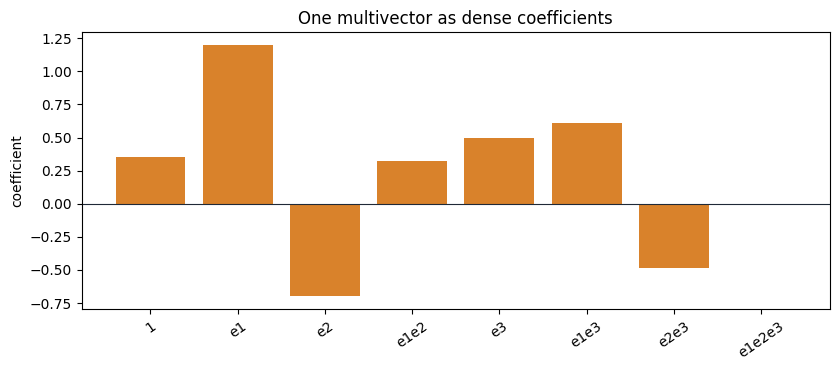

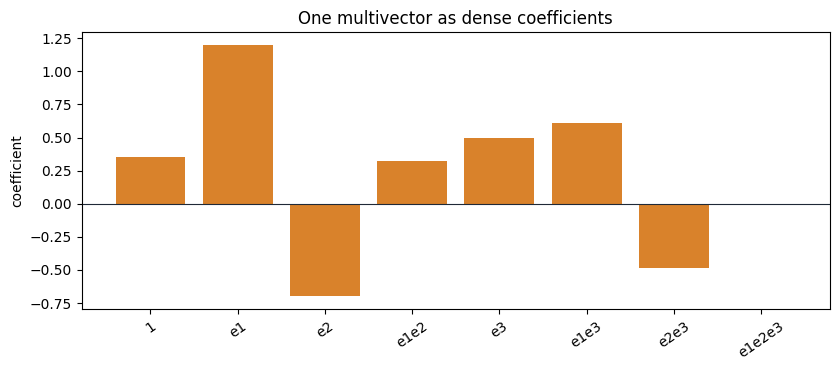

In [4]:
a = ga3.vector([1.2, -0.7, 0.5])
b = ga3.vector([-0.4, 0.9, 1.1])
bivector = ga3.outer_product(a, b)
mixed = ga3.scalar(0.35) + a + 0.4 * bivector
sparse_mixed = ga3.dense_to_sparse(mixed)
roundtrip = ga3.sparse_to_dense(sparse_mixed)
profile = operation_profile(ga3, mixed, bivector)

print("mixed multivector:", ga3.format_multivector(mixed))
print("sparse encoding:", {ga3.blade_names[k]: round(v, 4) for k, v in sparse_mixed.items()})
print("dense loop pairs:", profile["dense_basis_pairs"])
print("sparse loop pairs:", profile["sparse_basis_pairs"])

assert np.allclose(roundtrip, mixed)
assert profile["sparse_basis_pairs"] < profile["dense_basis_pairs"]

fig_coefficients = coefficient_bar_figure(ga3, mixed, title="One multivector as dense coefficients")
fig_coefficients.savefig(ARTIFACTS["coefficient_png"], dpi=160)
fig_coefficients

In [5]:
ga4 = OrthonormalAlgebra((1, 1, 1, 1), names=("e1", "e2", "e3", "e4"))
factors = np.array(
    [
        [1.0, 0.2, -0.4, 0.5],
        [-0.3, 0.8, 0.6, -0.1],
        [0.2, -0.5, 0.1, 1.1],
    ]
)
factored = FactoredBlade(factors)
expanded_sparse = factored.expanded_sparse()
expanded_dense = ga4.sparse_to_dense(expanded_sparse)
via_outer = ga4.outer_product(
    ga4.outer_product(ga4.vector(factors[0]), ga4.vector(factors[1])),
    ga4.vector(factors[2]),
)

print("factored storage slots:", factored.storage_size)
print("expanded nonzero coordinates:", len(expanded_sparse))
print("expanded blade:", ga4.format_multivector(expanded_dense))

assert np.allclose(expanded_dense, via_outer)
assert factored.grade == 3
assert factored.dimension == 4

factored storage slots: 12
expanded nonzero coordinates: 4
expanded blade: 0.414 e1e2e3 + 0.887 e1e2e4 + 0.471 e1e3e4 + 0.656 e2e3e4


## Matrix Representations: Useful, But Not The Whole Language

Because the geometric product is associative and distributive, small Clifford algebras can be represented by matrix algebras. For Euclidean Cl(2,0), a general element `x0 + x1 e1 + x2 e2 + x12 e1e2` can be encoded as a real 2-by-2 matrix. Matrix multiplication then matches the geometric product. For Euclidean Cl(3,0), one compact representation uses complex 2-by-2 matrices. These representations are mathematically elegant and useful for verification.

The catch is that matrix multiplication mostly serves the geometric product. A geometric algebra implementation usually also needs grade projection, outer products, contractions, reverse, involutions, norms, factorizations, and model-specific predicates. If the matrix representation is the only thing exposed, those operations must be reconstructed or implemented in parallel. That is why the notebook treats matrix forms as a check and a tool, not as a replacement for explicit geometric coordinates.


x: 0.8 + 1.2 e1 - 0.4 e2 + 0.35 e1e2
y: -0.2 + 0.7 e1 + 1.1 e2 - 0.5 e1e2
x*y: 0.415 + 0.505 e1 + 0.115 e2 + 1.13 e1e2
matrix product error: 4.002966042486721e-16


C:\Users\rahul\AppData\Local\Temp\ipykernel_30964\552699006.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


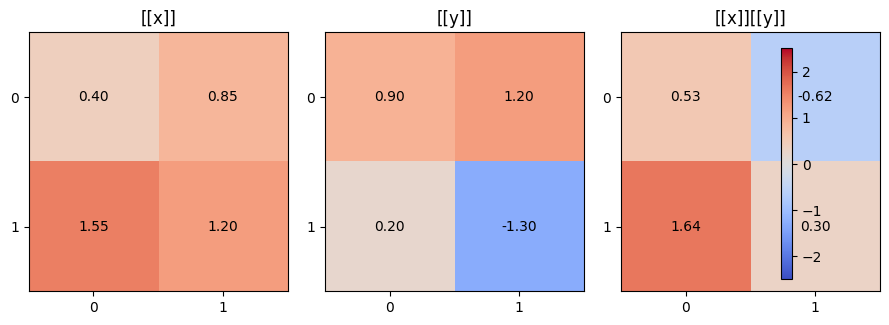

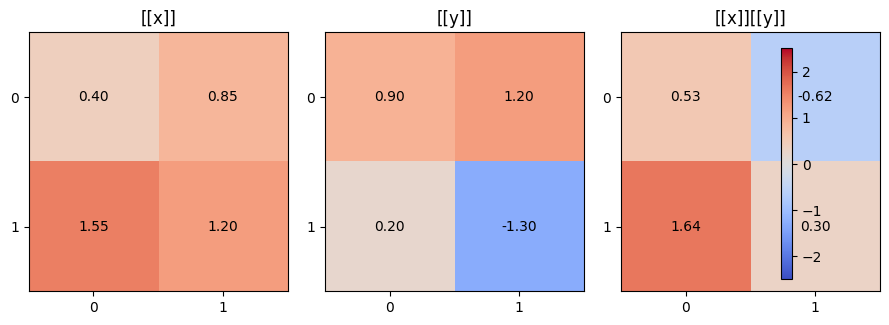

In [6]:
ga2 = OrthonormalAlgebra((1, 1), names=("e1", "e2"))
x = np.array([0.8, 1.2, -0.4, 0.35])
y = np.array([-0.2, 0.7, 1.1, -0.5])
xy = ga2.dense_product(x, y)
Mx = ga2_to_matrix(x)
My = ga2_to_matrix(y)
Mxy = ga2_to_matrix(xy)

print("x:", ga2.format_multivector(x))
print("y:", ga2.format_multivector(y))
print("x*y:", ga2.format_multivector(xy))
print("matrix product error:", np.linalg.norm(Mxy - Mx @ My))

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, matrix, title in zip(axes, [Mx, My, Mx @ My], ["[[x]]", "[[y]]", "[[x]][[y]]"]):
    image = ax.imshow(matrix, cmap="coolwarm", vmin=-2.5, vmax=2.5)
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(image, ax=axes, fraction=0.035)
fig.tight_layout()
fig.savefig(ARTIFACTS["ga2_matrix_png"], dpi=160)

assert np.allclose(Mxy, Mx @ My)
assert matrix_basis_product_error(ga2, ga2_matrix_basis()) < 1e-12
fig

In [7]:
basis_error_cl3 = matrix_basis_product_error(ga3, ga3_complex_matrix_basis())
vector = ga3.vector([0.6, -1.4, 0.8])
M = ga3_to_complex_matrix(vector)
vector_square = ga3.dense_product(vector, vector)[0]
complex_square = M @ M

print("Cl(3,0) basis representation error:", basis_error_cl3)
print("vector squared from GA:", vector_square)
print("matrix square residual:", np.linalg.norm(complex_square - vector_square * np.eye(2)))

assert basis_error_cl3 < 1e-12
assert np.allclose(complex_square, vector_square * np.eye(2))

Cl(3,0) basis representation error: 0.0
vector squared from GA: 2.96
matrix square residual: 3.7682219008410604e-17


## Symbolic Bootstrap, Numeric Runtime

A symbolic algebra system is excellent for deriving formulas, checking sign conventions, and generating specialized code. It is usually a poor choice for the inner loop of a numerical geometry application. Chapter 18 draws that boundary clearly: symbolic manipulation can bootstrap an implementation, but runtime geometry should use numerical data structures.

The small experiment below derives the Cl(2,0) geometric product formula with SymPy. That gives a readable expression for each output coordinate. Then the same formula is checked against the numeric dense product. This is a miniature version of a common production workflow: use symbolic or generative tools to create and audit code, then execute a compact numeric kernel in the application.


In [8]:
x_symbols = sp.symbols("x0 x1 x2 x12")
y_symbols = sp.symbols("y0 y1 y2 y12")


def symbolic_product(algebra: OrthonormalAlgebra, left, right):
    result = [sp.Integer(0) for _ in range(algebra.size)]
    for left_mask, left_value in enumerate(left):
        for right_mask, right_value in enumerate(right):
            factor, result_mask = algebra.blade_product(left_mask, right_mask)
            result[result_mask] += sp.Integer(int(factor)) * left_value * right_value
    return [sp.expand(expr) for expr in result]


symbolic_xy = symbolic_product(ga2, x_symbols, y_symbols)
operation_counts = [int(sp.count_ops(expr)) for expr in symbolic_xy]

with ARTIFACTS["symbolic_txt"].open("w", encoding="utf-8") as handle:
    for name, expr in zip(ga2.blade_names, symbolic_xy):
        handle.write(f"{name}: {sp.sstr(expr)}\n")

subs = {symbol: value for symbol, value in zip((*x_symbols, *y_symbols), (*x, *y))}
symbolic_numeric = np.array([float(expr.subs(subs)) for expr in symbolic_xy])

fig_ops = go.Figure(
    data=[
        go.Bar(
            x=ga2.blade_names,
            y=operation_counts,
            marker={"color": COLORS["purple"]},
        )
    ]
)
fig_ops.update_layout(
    title="Symbolic formula complexity by output coordinate",
    width=720,
    height=420,
    xaxis_title="output coordinate",
    yaxis_title="SymPy operation count",
)
fig_ops.write_html(ARTIFACTS["symbolic_ops_html"], include_plotlyjs="cdn")

print("symbolic product coordinates:")
for name, expr in zip(ga2.blade_names, symbolic_xy):
    print(f"  {name:4s}: {expr}")
print("numeric residual:", np.linalg.norm(symbolic_numeric - xy))

assert np.allclose(symbolic_numeric, xy)
fig_ops

symbolic product coordinates:
  1   : x0*y0 + x1*y1 - x12*y12 + x2*y2
  e1  : x0*y1 + x1*y0 + x12*y2 - x2*y12
  e2  : x0*y2 + x1*y12 - x12*y1 + x2*y0
  e1e2: x0*y12 + x1*y2 + x12*y0 - x2*y1
numeric residual: 6.206335383118183e-17


## Storage Growth And Sparsity

The phrase `2^n coordinates` is true but incomplete. A full multivector in an `n`-dimensional vector space has `2^n` basis coordinates. A pure grade-2 object has only `n choose 2` possible coordinates. A factored 2-blade can be stored as two length-`n` vectors. These counts do not settle every engineering decision, but they explain why implementations often specialize by grade, known object type, or application model.

For low-dimensional computer-graphics algebras, dense coordinates may be entirely reasonable. For a conformal model with fixed dimension, a carefully specialized dense layout can be very fast. For higher-dimensional algebras or algorithms that preserve simple blades, sparse and factored representations can change an impossible memory profile into a manageable one. The right question is not just how many coordinates exist; it is how many coordinates the algorithm actually touches.


In [9]:
profiles = storage_profile(max_dimension=12, blade_grade=2)
with ARTIFACTS["storage_csv"].open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(profiles[0]))
    writer.writeheader()
    writer.writerows(profiles)

fig_storage = storage_profile_figure(profiles)
fig_storage.write_html(ARTIFACTS["storage_html"], include_plotlyjs="cdn")

print("n=12 dense slots:", profiles[-1]["dense_multivector"])
print("n=12 grade-2 slots:", profiles[-1]["single_grade"])
print("n=12 factored 2-blade slots:", profiles[-1]["factored_blade"])

assert profiles[-1]["dense_multivector"] == 4096
assert profiles[-1]["single_grade"] == 66
assert profiles[-1]["factored_blade"] == 24
fig_storage

n=12 dense slots: 4096
n=12 grade-2 slots: 66
n=12 factored 2-blade slots: 24


## Testing Strategy

Implementation chapters need tests that are more structural than example-based. A few hand-computed products are useful, but they do not protect the whole algebra. Better tests ask whether the implementation preserves identities that must hold across many random inputs and signatures.

The cell below checks associativity of the geometric product, distributivity, agreement between dense and sparse products, anti-symmetry of the vector outer product, matrix-representation preservation, and inverse residuals in Cl(2,0). These are not a complete production test suite, but they are the right shape: each test is tied to an algebraic invariant rather than to a fragile display value.

The important habit is to test each layer. Basis-blade product tables should be checked independently. Dense and sparse encodings should agree. Matrix representations should be verified against the coordinate engine. Nonlinear algorithms should report residuals, not just return values. Application code should assert geometric invariants such as incidence, normalization, or distance preservation.


In [10]:
test_rows = []
for signature in [(1, 1), (1, 1, 1), (1, -1, 1)]:
    algebra = OrthonormalAlgebra(signature)
    a_rand = rng.normal(size=algebra.size)
    b_rand = rng.normal(size=algebra.size)
    c_rand = rng.normal(size=algebra.size)
    assoc = np.linalg.norm(
        algebra.dense_product(algebra.dense_product(a_rand, b_rand), c_rand)
        - algebra.dense_product(a_rand, algebra.dense_product(b_rand, c_rand))
    )
    distrib = np.linalg.norm(
        algebra.dense_product(a_rand, b_rand + c_rand)
        - algebra.dense_product(a_rand, b_rand)
        - algebra.dense_product(a_rand, c_rand)
    )
    sparse = np.linalg.norm(
        algebra.dense_product(a_rand, b_rand)
        - algebra.sparse_to_dense(
            algebra.sparse_product(algebra.dense_to_sparse(a_rand), algebra.dense_to_sparse(b_rand))
        )
    )
    v = algebra.vector(rng.normal(size=algebra.dimension))
    w = algebra.vector(rng.normal(size=algebra.dimension))
    outer_antisymmetry = np.linalg.norm(algebra.outer_product(v, w) + algebra.outer_product(w, v))
    test_rows.extend(
        [
            {"test": f"associativity {signature}", "residual": float(assoc)},
            {"test": f"distributivity {signature}", "residual": float(distrib)},
            {"test": f"dense/sparse {signature}", "residual": float(sparse)},
            {"test": f"outer antisymmetry {signature}", "residual": float(outer_antisymmetry)},
        ]
    )

inverse_candidate = np.array([1.2, 0.2, -0.1, 0.35])
inverse = ga2_inverse_via_matrix(inverse_candidate)
inverse_residual = np.linalg.norm(ga2.dense_product(inverse_candidate, inverse) - ga2.scalar(1.0))
test_rows.append({"test": "Cl(2,0) matrix inverse", "residual": float(inverse_residual)})

with ARTIFACTS["test_residuals_json"].open("w", encoding="utf-8") as handle:
    json.dump(test_rows, handle, indent=2)

fig_tests = go.Figure(
    data=[
        go.Bar(
            x=[row["test"] for row in test_rows],
            y=[max(row["residual"], 1e-18) for row in test_rows],
            marker={"color": COLORS["green"]},
        )
    ]
)
fig_tests.update_layout(
    title="Implementation invariant residuals",
    width=950,
    height=500,
    yaxis={"title": "residual (log scale)", "type": "log"},
    xaxis={"tickangle": 35},
    margin={"l": 75, "r": 20, "t": 55, "b": 150},
)
fig_tests.write_html(ARTIFACTS["test_residuals_html"], include_plotlyjs="cdn")

max_residual = max(row["residual"] for row in test_rows)
print("max residual:", max_residual)
assert max_residual < 1e-10
fig_tests

max residual: 6.0402662910232525e-15


## How Choices Influence Later Algorithms

The rest of Part III depends on the choices introduced here. Chapter 19 benefits from the bit-mask view because products of basis blades become Boolean-looking operations plus metric factors. Chapter 20 benefits from a linear coordinate view because many operations distribute over sums. Chapter 21 needs access to coordinates and grades because nonlinear operations such as meet, join, inverse, and factorization are not just matrix multiplication. Chapter 22 specializes the structure so applications can keep the geometric language without paying an unnecessary generality tax.

The small cost model below compares two multiplication loops in an 8-dimensional Euclidean algebra. A dense loop touches all possible basis-blade pairs. A sparse loop touches only active terms. For a random grade-2 blade multiplied by a vector, the sparse pair count is tiny compared with the dense pair count. That does not mean sparse is always faster in real software; memory layout, branch prediction, specialization, and generated code matter. It does show why representation should be chosen with the expected algorithm in mind.


In [11]:
ga8 = OrthonormalAlgebra(tuple([1] * 8))
vectors8 = rng.normal(size=(2, 8))
blade8 = ga8.sparse_to_dense(wedge_vectors(vectors8))
vector8 = ga8.vector(rng.normal(size=8))
product_profile = operation_profile(ga8, blade8, vector8)

policy_rows = [
    {
        "situation": "small fixed algebra with many mixed-grade operations",
        "likely_representation": "specialized dense coordinates",
    },
    {
        "situation": "structured blades or versors with few active terms",
        "likely_representation": "sparse coordinates or generated sparse kernels",
    },
    {
        "situation": "high-dimensional blades manipulated as spans",
        "likely_representation": "factored blade representation",
    },
    {
        "situation": "formula derivation and code generation",
        "likely_representation": "symbolic bootstrap, numeric runtime",
    },
    {
        "situation": "checking small Clifford algebra products",
        "likely_representation": "matrix representation as an oracle",
    },
]
with ARTIFACTS["representation_policy_json"].open("w", encoding="utf-8") as handle:
    json.dump(policy_rows, handle, indent=2)

fig_costs = go.Figure(
    data=[
        go.Bar(
            x=["dense basis pairs", "sparse active pairs"],
            y=[product_profile["dense_basis_pairs"], product_profile["sparse_basis_pairs"]],
            marker={"color": [COLORS["red"], COLORS["blue"]]},
        )
    ]
)
fig_costs.update_layout(
    title="An 8-D grade-2 blade times a vector: loop-pair count",
    width=720,
    height=430,
    yaxis={"title": "candidate basis-pair products", "type": "log"},
)
fig_costs.write_html(ARTIFACTS["algorithm_costs_html"], include_plotlyjs="cdn")

print(product_profile)
assert product_profile["sparse_basis_pairs"] < product_profile["dense_basis_pairs"] / 100
fig_costs

{'dense_basis_pairs': 65536, 'sparse_basis_pairs': 224, 'left_nonzero': 28, 'right_nonzero': 8}


## Final Sanity Checks

The final cells make the notebook act like a small quality gate. They verify helper-level invariants and confirm that the notebook wrote its artifacts under `artifacts/chapter-18`. This is especially useful in a shared repository because the notebook can be executed independently of other workers' chapter folders.


In [12]:
checks = helper_sanity_checks()
for name, residual in checks.items():
    print(f"{name:32s} {residual:.3e}")

thresholded = {key: value for key, value in checks.items() if "storage" not in key}
assert all(value < 1e-9 for value in thresholded.values())
assert checks["storage_dense_n12"] == 4096.0

ga2_matrix_product_error         9.696e-16
ga2_basis_error                  0.000e+00
ga3_complex_product_error        9.550e-16
ga3_basis_error                  0.000e+00
dense_sparse_product_error       0.000e+00
factored_outer_error             1.700e-17
matrix_inverse_identity_error    6.546e-17
storage_dense_n12                4.096e+03


In [13]:
missing = [path for path in ARTIFACTS.values() if not path.exists()]
small = [path for path in ARTIFACTS.values() if path.exists() and path.stat().st_size == 0]
print("artifact count:", len(ARTIFACTS))
for name, path in ARTIFACTS.items():
    print(f"{name:28s} {path.relative_to(BOOK_ROOT)} ({path.stat().st_size} bytes)")

assert not missing
assert not small

artifact count: 13
levels_html                  artifacts\chapter-18\implementation-level-costs.html (8259 bytes)
levels_csv                   artifacts\chapter-18\implementation-level-costs.csv (157 bytes)
product_table_html           artifacts\chapter-18\basis-product-table.html (9999 bytes)
coefficient_png              artifacts\chapter-18\encoding-coefficients.png (34143 bytes)
ga2_matrix_png               artifacts\chapter-18\ga2-matrix-representation.png (26779 bytes)
symbolic_txt                 artifacts\chapter-18\symbolic-ga2-product.txt (149 bytes)
symbolic_ops_html            artifacts\chapter-18\symbolic-operation-counts.html (7831 bytes)
storage_html                 artifacts\chapter-18\storage-profile.html (8369 bytes)
storage_csv                  artifacts\chapter-18\storage-profile.csv (202 bytes)
test_residuals_html          artifacts\chapter-18\implementation-test-residuals.html (8370 bytes)
test_residuals_json          artifacts\chapter-18\implementation-test-residu

## Chapter Takeaways

Chapter 18 is a reminder that a geometric algebra implementation is not a single trick. It is a stack of choices. At the bottom, basis blades need reliable names, signs, metric factors, and product tests. Above that, multivectors need coordinate encodings that match the dimension and sparsity of the problem. Matrix representations are valuable for small Clifford algebras and for verification, but they should not erase the grade-aware operations that make geometric algebra useful. Symbolic systems can derive and audit formulas, while numerical kernels should do the repeated work.

The practical rule is to let the object and algorithm choose the representation. Dense coordinates are friendly for small fixed algebras and mixed-grade objects. Sparse coordinates fit structured elements with few active terms. Factored blades are compelling when high-dimensional spans matter more than expanded coordinates. Nonlinear algorithms deserve their own tests and numerical safeguards. Application code should sit above these details and use geometric operations directly.

That is the bridge into the next chapters: first make the basis-blade machinery trustworthy, then build linear products, then treat nonlinear operations as algorithms rather than as mere coordinate loops, and finally specialize where performance matters.
